Loading Flip-Flop training snapshots...
Full Field: 29161 points | Sensor: 363 points
Computing Full-Field POD (up to 726 modes)...
Computing Sensor Strip POD...
Computing Observability Matrix (R_ij)...
Generating Plots...


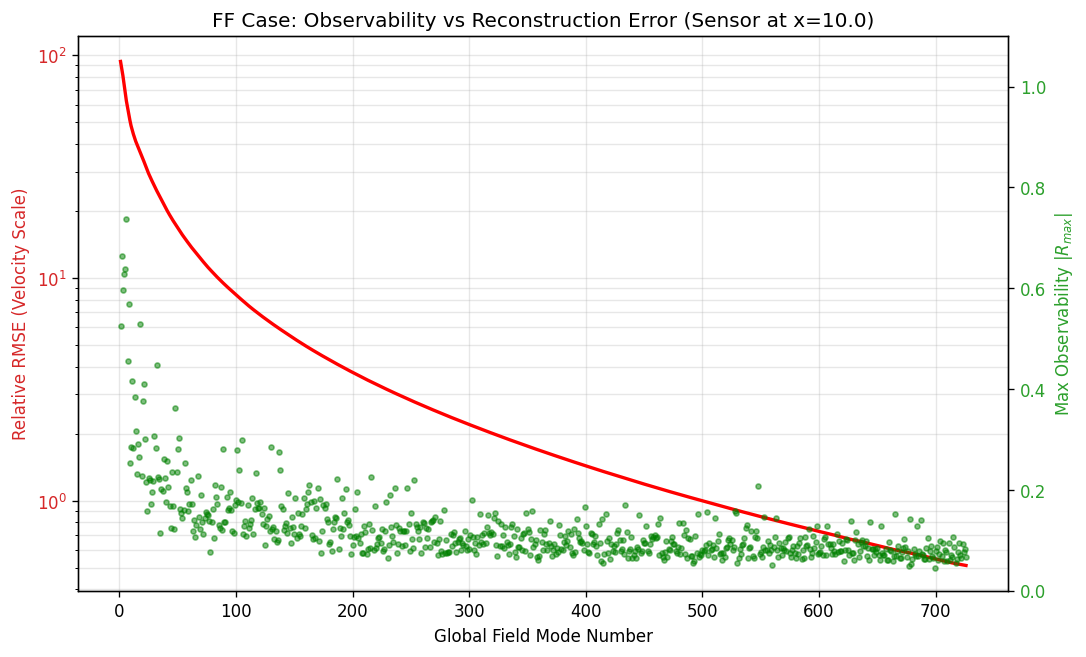

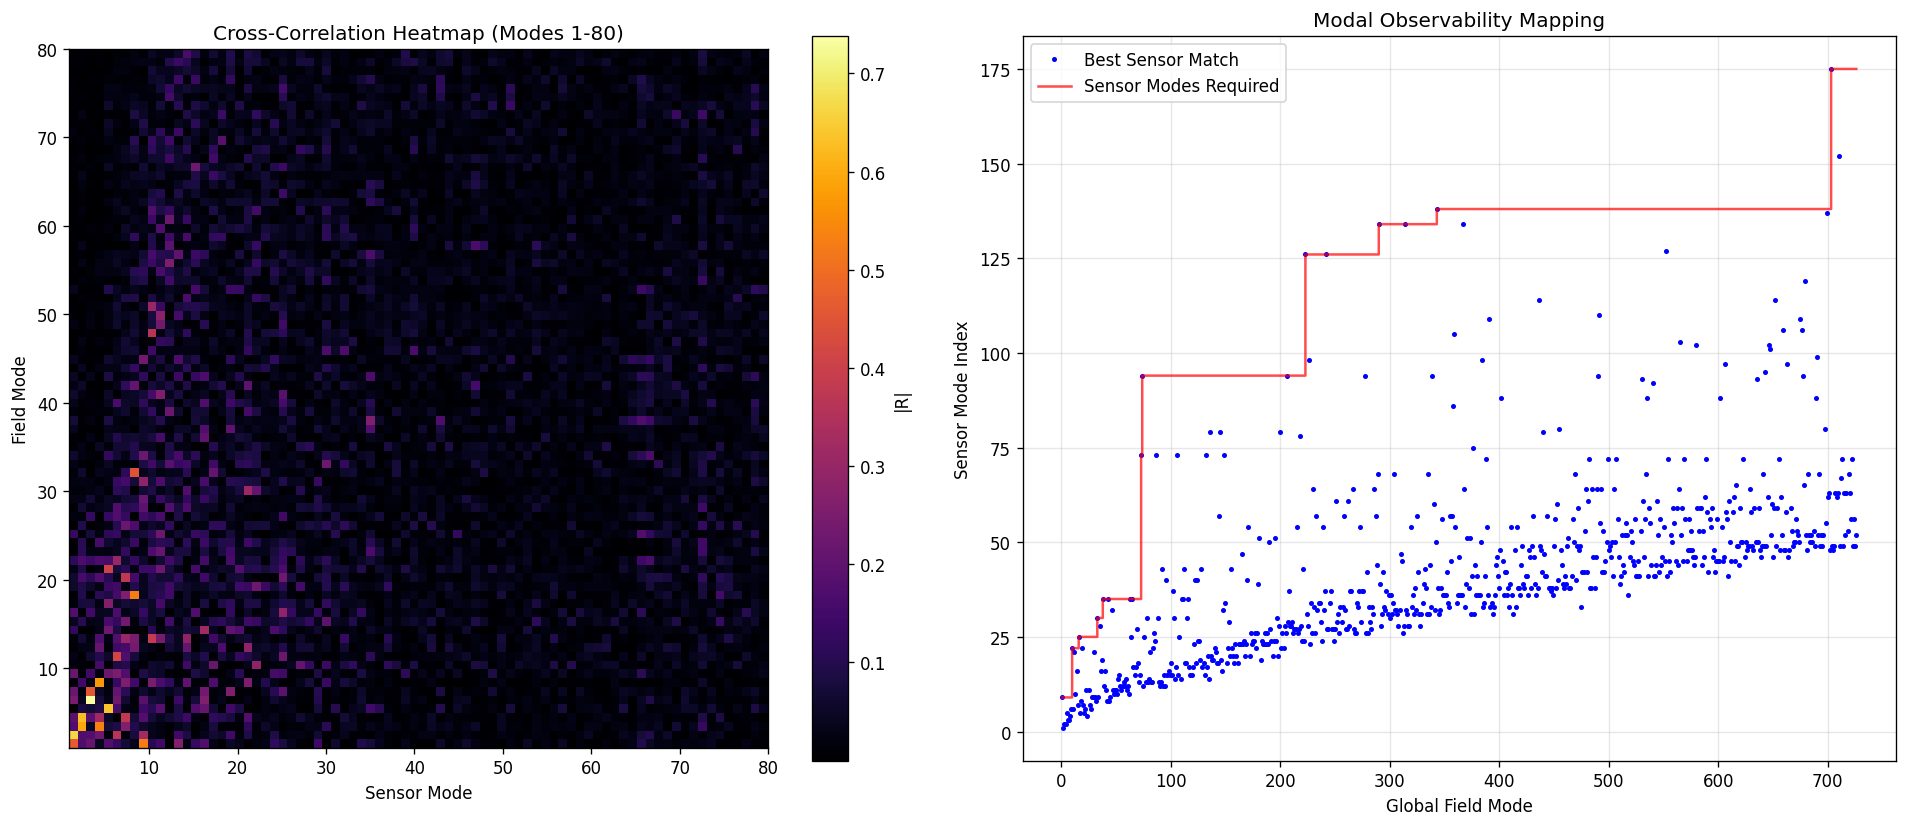


FLIP-FLOP (FF) POD OBSERVABILITY REPORT
10% Vel Error: Needs 85 Field Modes | Requires 94 Sensor Modes
5% Vel Error: Needs 159 Field Modes | Requires 94 Sensor Modes
1% Vel Error: Needs 500 Field Modes | Requires 138 Sensor Modes
--------------------------------------------------
Observability of Primary Modes:
  Field Mode  1 -> Sensor Mode  9 | R = 0.5254
  Field Mode  2 -> Sensor Mode  1 | R = 0.6641
  Field Mode  3 -> Sensor Mode  2 | R = 0.5959
  Field Mode  4 -> Sensor Mode  2 | R = 0.6280
  Field Mode  5 -> Sensor Mode  5 | R = 0.6379
  Field Mode  6 -> Sensor Mode  3 | R = 0.7381
  Field Mode  7 -> Sensor Mode  3 | R = 0.4565
  Field Mode  8 -> Sensor Mode  4 | R = 0.5693
  Field Mode  9 -> Sensor Mode  6 | R = 0.2533
  Field Mode 10 -> Sensor Mode 22 | R = 0.2858


In [5]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# --- 1. CONFIGURATION ---
base_dir = "/media/chris-remote/Projects/ONeill/estimation"
output_dir = os.path.join(base_dir, "output/kevin_2cylinder")
unified_h5 = os.path.join(output_dir, "flipflop_velocity_unified.h5")

# Near-wake sensor strip parameters
SENSOR_X = 10.0
TOLERANCE = 0.1


# Output subfolder for FF diagnostics
diag_dir = os.path.join(output_dir, "diagnostics_FF")
os.makedirs(diag_dir, exist_ok=True)

# --- 2. LOAD DATA ---
print("Loading Flip-Flop training snapshots...")
with h5py.File(unified_h5, 'r') as f:
    x = f['x'][:]
    y = f['y'][:]
    ux_train = f['train/ux'][:]
    uy_train = f['train/uy'][:]

# Extract Sensor Strip indices (x=5)
sensor_mask = np.abs(x - SENSOR_X) < TOLERANCE
sensor_idx = np.where(sensor_mask)[0]
sensor_idx = sensor_idx[np.argsort(y[sensor_idx])]

print(f"Full Field: {ux_train.shape[1]} points | Sensor: {len(sensor_idx)} points")

MAX_MODES = 2*len(sensor_idx) # FF needs more modes than MP to reach 1% error

# --- 3. COMPUTE VECTOR PODs ---
print(f"Computing Full-Field POD (up to {MAX_MODES} modes)...")
S_full = np.hstack([ux_train, uy_train])
mean_full = np.mean(S_full, axis=0)
pca_full = PCA(n_components=MAX_MODES, svd_solver='randomized', random_state=42)
a_full = pca_full.fit_transform(S_full - mean_full)

print(f"Computing Sensor Strip POD...")
# Strip features = points * 2 (u and v)
S_strip = np.hstack([ux_train[:, sensor_idx], uy_train[:, sensor_idx]])
mean_strip = np.mean(S_strip, axis=0)
# Capping sensor modes at the rank limit (points * 2) or MAX_MODES
n_sensor_modes = min(MAX_MODES, S_strip.shape[1])
pca_strip = PCA(n_components=n_sensor_modes, svd_solver='randomized', random_state=42)
a_strip = pca_strip.fit_transform(S_strip - mean_strip)

# --- 4. CROSS-CORRELATION & OBSERVABILITY ---
print("Computing Observability Matrix (R_ij)...")
# Standardize coefficients so dot product = correlation
a_f_norm = StandardScaler().fit_transform(a_full)
a_s_norm = StandardScaler().fit_transform(a_strip)

# R[i, j] is the correlation between Field Mode i and Sensor Mode j
R = (a_f_norm.T @ a_s_norm) / len(a_f_norm)
abs_R = np.abs(R)

# Analytics
max_corr_per_field_mode = np.max(abs_R, axis=1)
best_sensor_match = np.argmax(abs_R, axis=1)
# Staircase: How many sensor modes are needed to observe field modes 1...N
req_sensor_modes = [np.max(best_sensor_match[:i+1]) + 1 for i in range(MAX_MODES)]

# Velocity-Scale Error Metric
cum_energy_ratio = np.cumsum(pca_full.explained_variance_ratio_)
l2_error_vel = np.sqrt(np.maximum(1 - cum_energy_ratio, 0))

# --- 5. PLOTTING ---
print("Generating Plots...")

# FIGURE 1: Convergence & Observability
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120)
ax1.set_xlabel('Global Field Mode Number')
ax1.set_ylabel('Relative RMSE (Velocity Scale)', color='tab:red')
ax1.plot(range(1, MAX_MODES+1), l2_error_vel * 100, 'r-', linewidth=2, label='L2 Error %')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, which='both', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(range(1, MAX_MODES+1), max_corr_per_field_mode, 'g.', alpha=0.5, label='Max Correlation')
ax2.set_ylabel('Max Observability $|R_{max}|$', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(0, 1.1)

plt.title(f"FF Case: Observability vs Reconstruction Error (Sensor at x={SENSOR_X})")
plt.savefig(os.path.join(diag_dir, "FF_convergence_observability.png"))

# FIGURE 2: Correlation Mapping
fig, (ax_h, ax_m) = plt.subplots(1, 2, figsize=(16, 7), dpi=120)

# Heatmap (First 80 modes to see chaotic structures)
im = ax_h.imshow(abs_R[:80, :80], origin='lower', cmap='inferno', extent=[1, 80, 1, 80])
ax_h.set_title("Cross-Correlation Heatmap (Modes 1-80)")
ax_h.set_xlabel("Sensor Mode")
ax_h.set_ylabel("Field Mode")
plt.colorbar(im, ax=ax_h, label="|R|")

# Matching Staircase
ax_m.plot(range(1, MAX_MODES+1), best_sensor_match + 1, 'bo', markersize=2, label='Best Sensor Match')
ax_m.step(range(1, MAX_MODES+1), req_sensor_modes, 'r-', where='post', alpha=0.7, label='Sensor Modes Required')
ax_m.set_title("Modal Observability Mapping")
ax_m.set_xlabel("Global Field Mode")
ax_m.set_ylabel("Sensor Mode Index")
ax_m.legend()
ax_m.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(diag_dir, "FF_correlation_mapping.png"))
plt.show()

# --- 6. SUMMARY REPORT ---
print("\n" + "="*50)
print("FLIP-FLOP (FF) POD OBSERVABILITY REPORT")
print("="*50)
target_errs = [0.1, 0.05, 0.01]
for te in target_errs:
    idx = np.where(l2_error_vel <= te)[0]
    if len(idx) > 0:
        n_f = idx[0] + 1
        n_s_req = req_sensor_modes[idx[0]]
        print(f"{te*100:g}% Vel Error: Needs {n_f} Field Modes | Requires {n_s_req} Sensor Modes")

print("-" * 50)
print(f"Observability of Primary Modes:")
for i in range(10):
    print(f"  Field Mode {i+1:2d} -> Sensor Mode {best_sensor_match[i]+1:2d} | R = {max_corr_per_field_mode[i]:.4f}")
print("="*50)